# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [4]:
# Import the library
from PIL import Image, ImageOps
from skimage import data
import numpy as np
import matplotlib.pyplot as plt

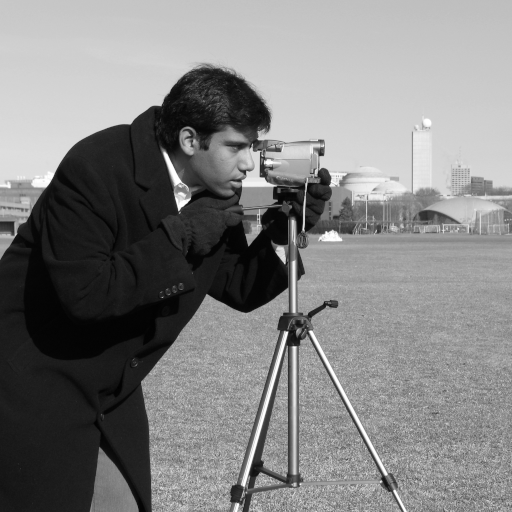

In [5]:
# ── Load image ────────────────────────────────────
img = Image.fromarray(data.camera()).convert("L")
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [6]:
# Get the size of the image
w, h = img.size
print("Original size (w, h):", (w, h))

# scaling factors
cx, cy = 2, 2

Original size (w, h): (512, 512)


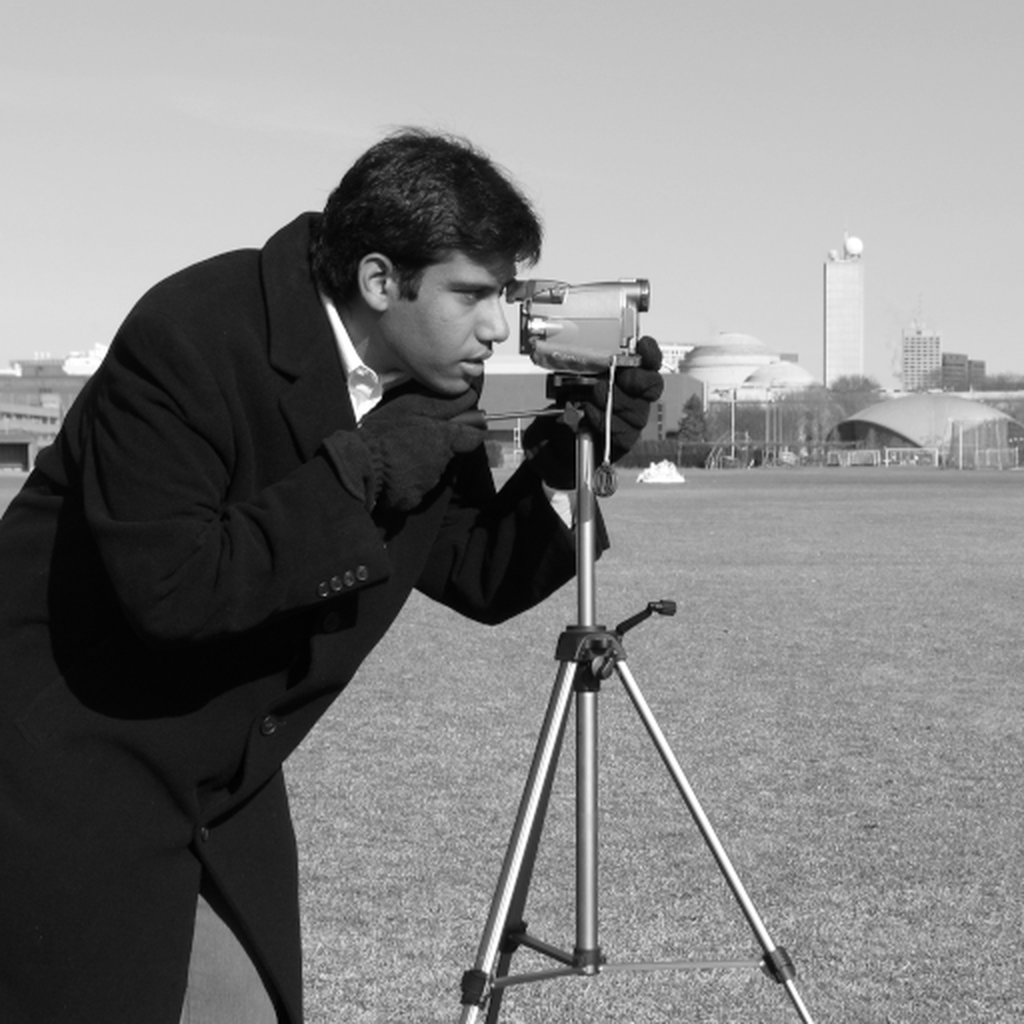

In [7]:
# # ── 1. Increase size (scale ×2) ──
new_size = (w * cx, h * cy)
scaled = img.resize(new_size, Image.LANCZOS)   # LANCZOS: high quality resampling
scaled

In [8]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled.save("task1.1_scaled.jpg")
print("Original:", img.size, "→ Scaled ×2:", scaled.size)

Original: (512, 512) → Scaled ×2: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

Non-uniform: (512, 512) → (1024, 512)


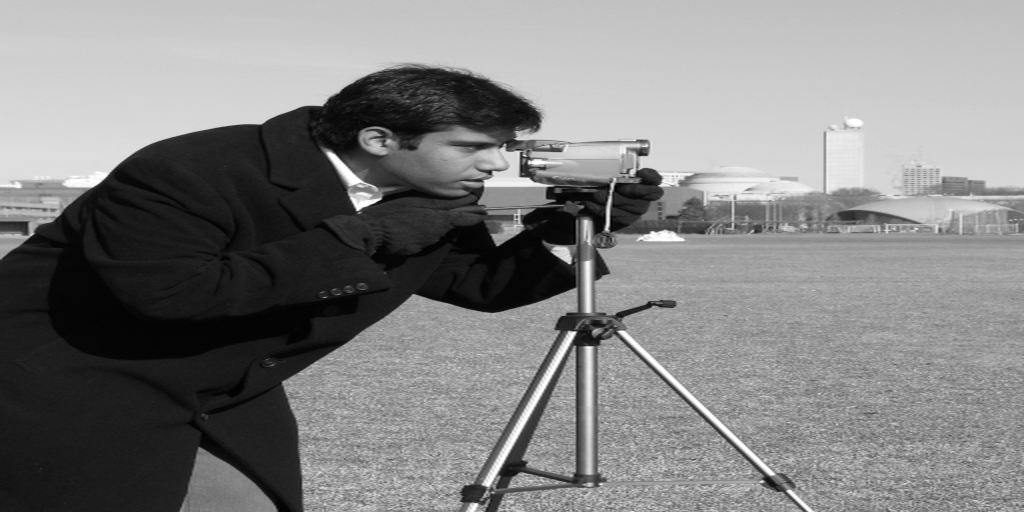

In [9]:
# non-uniform scale: stretch horizontally only
cx_nu, cy_nu = 2, 1
stretched = img.resize((w * cx_nu, h * cy_nu), Image.LANCZOS)
print("Non-uniform:", img.size, "→", stretched.size)
stretched

In [10]:
stretched.save("task1.1_stretched.jpg")

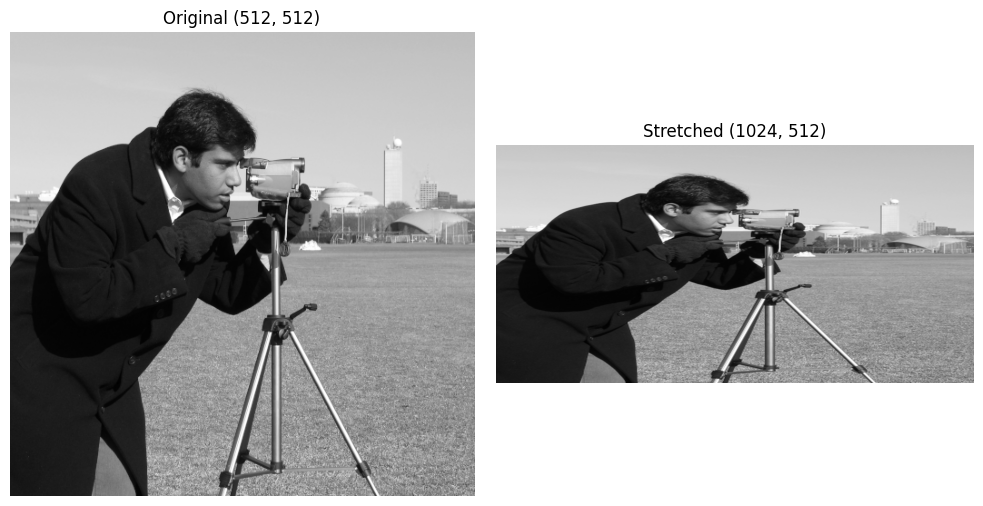

In [11]:
# comparison
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap="gray");       ax[0].set_title(f"Original {img.size}");       ax[0].axis("off")
ax[1].imshow(stretched, cmap="gray"); ax[1].set_title(f"Stretched {stretched.size}"); ax[1].axis("off")
plt.tight_layout(); plt.show()

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original: (512, 512) → Rotated 120°: (700, 700)


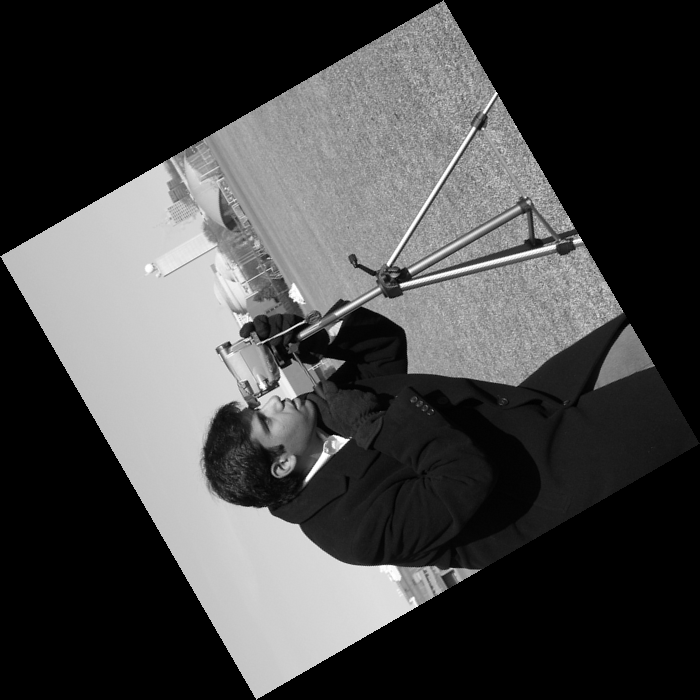

In [12]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated = img.rotate(120, expand=True, resample=Image.BICUBIC, fillcolor=0)
rotated.save("task1.2_rotated.jpg")
print("Original:", img.size, "→ Rotated 120°:", rotated.size)
rotated

### 3. Shear

In [13]:
# -- c. Get the image dimensions ────────────────────
w, h = img.size
print("Dimensions (w, h):", (w, h))

Dimensions (w, h): (512, 512)


In [14]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5        # horizontal shear factor
shy = 0.0        # vertical shear factor (0 = X-axis only)

# PIL affine: (a, b, c, d, e, f)
#   x_src = a*x + b*y + c
#   y_src = d*x + e*y + f
a, b, c = 1,   shx, 0
d, e, f = shy, 1,   0
coeffs = (a, b, c, d, e, f)
print("shear matrix:", coeffs)

shear matrix: (1, 0.5, 0, 0.0, 1, 0)


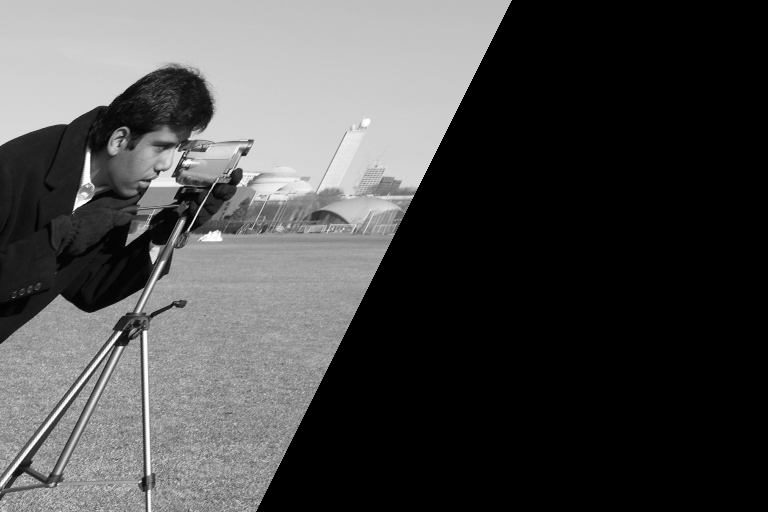

In [15]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
new_w = w + int(abs(shx) * h)
new_h = h + int(abs(shy) * w)

sheared = img.transform(
    (new_w, new_h),
    Image.AFFINE,
    coeffs,
    resample=Image.BICUBIC,
    fillcolor=0
)
sheared

In [16]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared.save("task1.3_sheared.jpg")
print("Original:", img.size, "→ Sheared:", sheared.size)

Original: (512, 512) → Sheared: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

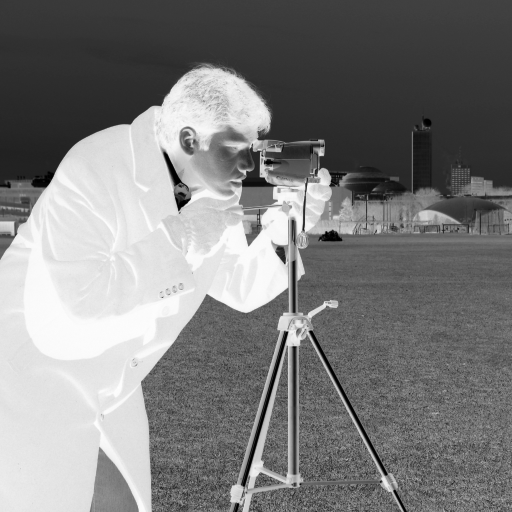

In [17]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
#s = 255 - r
arr = np.array(img)
neg_np = Image.fromarray((255 - arr).astype(np.uint8))
neg_np.save("task2.1_negative_numpy.jpg")
neg_np


Identical result: True


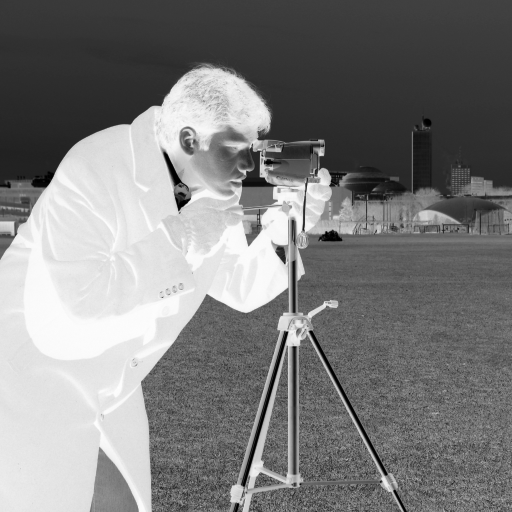

In [18]:
# Method 2: PIL's ImageOps
neg_pil = ImageOps.invert(img)
neg_pil.save("task2.1_negative_imageops.jpg")
print("Identical result:", np.array_equal(np.array(neg_np), np.array(neg_pil)))
neg_pil

c = 45.986


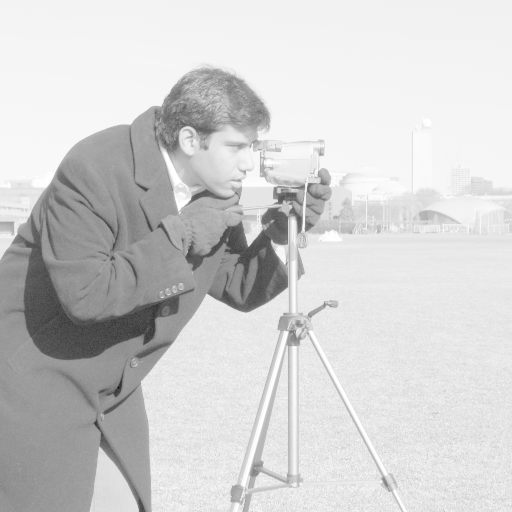

In [19]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
r = np.array(img, dtype=np.float64)
c = 255 / np.log(1 + 255)
print("c =", round(c, 3))

# Apply the log transformation to each pixel:  s = c · log(1 + r)
s = c * np.log(1 + r)
log_img = Image.fromarray(s.astype(np.uint8))
log_img.save("task2_2_log.jpg")
log_img

In [20]:
# ── 3. Power-law / Gamma correction ───────────────

# s = r^gamma  (normalize to [0,1] first)
norm = np.array(img, dtype=np.float64) / 255.0

gammas = [0.4, 1.0, 2.5]
gamma_imgs = {}
for g in gammas:
    gi = Image.fromarray((np.power(norm, g) * 255).astype(np.uint8))
    gi.save(f"task2.3_gamma_{g}.jpg")
    gamma_imgs[g] = gi
    print(f"gamma={g:<4} {'brightens' if g<1 else ('no change' if g==1 else 'darkens')}")

gamma=0.4  brightens
gamma=1.0  no change
gamma=2.5  darkens


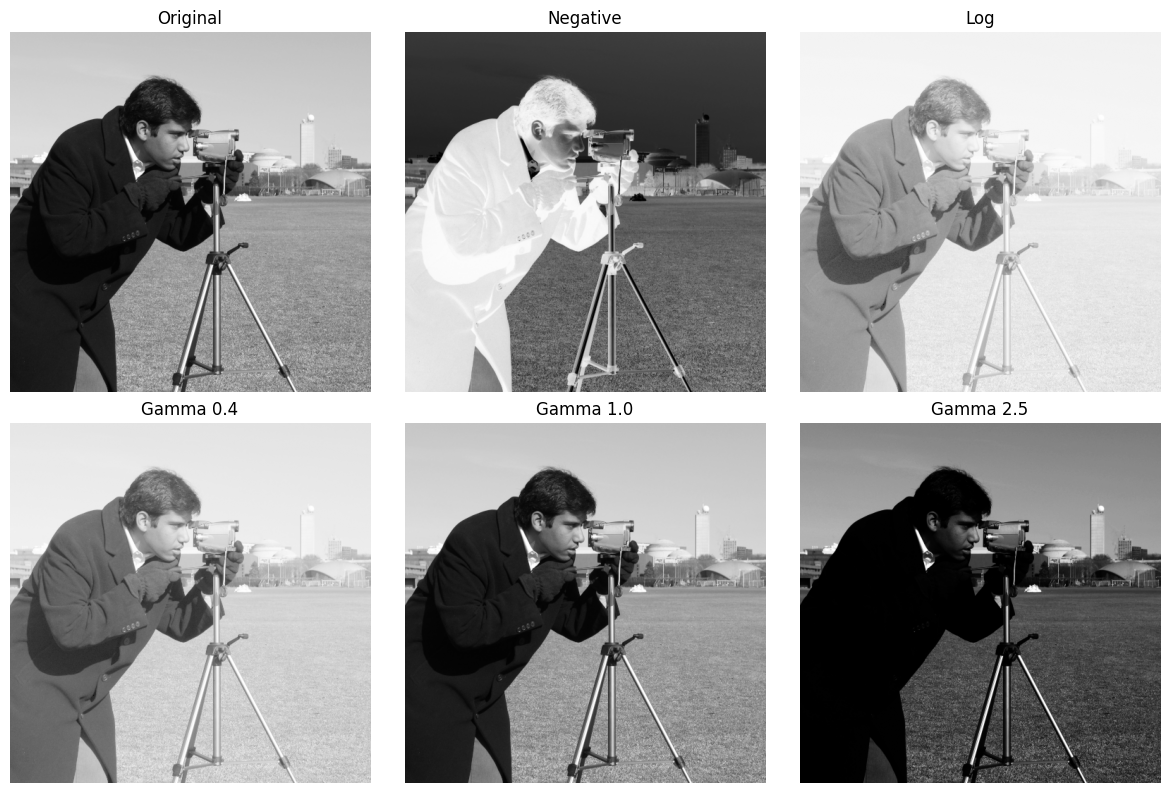

In [21]:
# ── Compare all intensity transforms ──
titles = ["Original", "Negative", "Log", "Gamma 0.4", "Gamma 1.0", "Gamma 2.5"]
images = [img, neg_pil, log_img, gamma_imgs[0.4], gamma_imgs[1.0], gamma_imgs[2.5]]

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
for a, t, im in zip(ax.ravel(), titles, images):
    a.imshow(im, cmap="gray"); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()